## Example search and download with CMIP6py

In this example we make a search, refine it, and download the data locally.

In [1]:
import os
import logging
import concurrent.futures

logger = logging.getLogger()
logger.setLevel(logging.INFO)

from cmip6py.search.cmip6_search import CMIP6Search

### Define wider search

In [2]:
search_facets = {"experiment_id": ["historical", "ssp245"], 
                 "source_id": ["EC-Earth3", "MPI-ESM1-2-HR"], 
                 "variable": ["ua", "va"],
                 "table_id": ["Eday", "day", "Oday"]}
search_filters = {
    "experiment_id": ["historical", "ssp245"],
    "years": {"historical": [2010, 2015], "projections": [2015, 2021]},
}
strict_variable_set = search_facets["variable"]

### Perform search

In [3]:
cmip6_search = CMIP6Search(
    random_seed=42, 
    max_workers=os.cpu_count(),
)
cmip6_search.search(search_facets)
cmip6_search

INFO:cmip6py.search.search_utils:Submitted 8 parallel searches (max_workers=12)
INFO:cmip6py.search.search_utils:Got 240 results from https://esgf.ceda.ac.uk/esg-search (variable=va, exp=ssp245)
INFO:cmip6py.search.search_utils:Got 248 results from https://esgf.ceda.ac.uk/esg-search (variable=ua, exp=ssp245)
INFO:cmip6py.search.search_utils:Got 240 results from https://esgf-node.llnl.gov/esg-search (variable=va, exp=ssp245)
INFO:cmip6py.search.search_utils:Got 248 results from https://esgf-node.llnl.gov/esg-search (variable=ua, exp=ssp245)
INFO:cmip6py.search.search_utils:Got 144 results from https://esgf-data.dkrz.de/esg-search (variable=ua, exp=ssp245)
INFO:cmip6py.search.search_utils:Got 1419 results from https://esgf.ceda.ac.uk/esg-search (variable=va, exp=historical)
INFO:cmip6py.search.search_utils:Got 1420 results from https://esgf.ceda.ac.uk/esg-search (variable=ua, exp=historical)
INFO:cmip6py.search.search_utils:Got 144 results from https://esgf-data.dkrz.de/esg-search (varia

CMIP6Search:random_seed=42,n_datasets=368,nodes_are_filtered=False,members_are_balanced=False

/Users/eliotwalt/Documents/phd/code/CMIP6py/cmip6py/search/cmip6_search.py:305: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().remove()


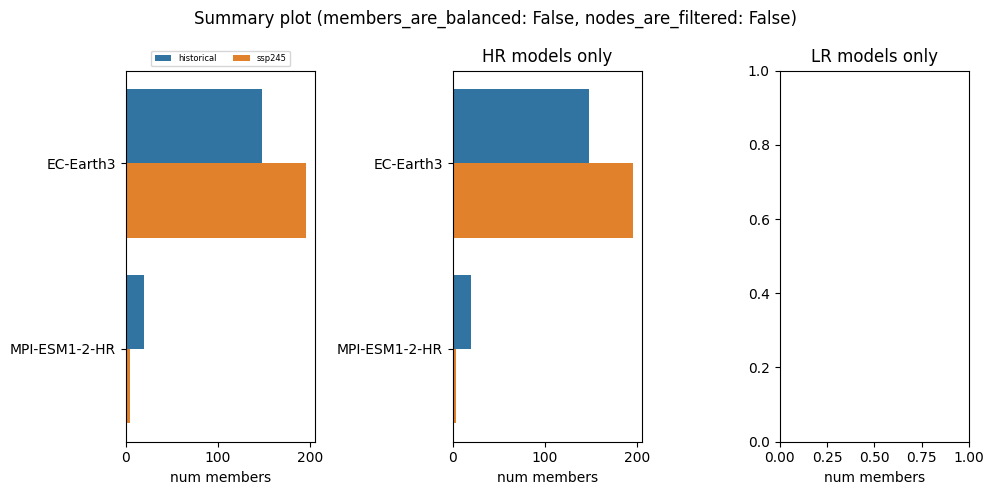

In [4]:
cmip6_search.summary_plot()

### Refine the search

Let's say that in the end we only want the historical runs (but for models that we know will also have the ssp245 run) and for years 2010 to 2014 included. Also, we want 2 +- 1 member (i.e. at most 3, at least 1).

In [5]:
filtered_cmip6_search = (cmip6_search.filter("facets", experiment_id=["historical"]) # only historical
                                     .filter("years", historical=[2010, 2015]) # select only a few years
                                     .filter("running_nodes")
                                     .balance_members(num_members=2, tolerance=1)) # select years
filtered_cmip6_search.summary_plot()

Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

### Split and download locally

Ideally we would split the final search and quickly (before the ESGF node status changes) run the downloads in parallel. We emulate that here by splitting and download a single sub-search.

In [ ]:
split_cmip6_searches = filtered_cmip6_search.splitby(["source_id", "member_id"]) # split by source_id and member_id
split_cmip6_searches

[CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True,
 CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True,
 CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True,
 CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True,
 CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True,
 CMIP6Search:random_seed=42,n_datasets=1,nodes_are_filtered=True,members_are_balanced=True]

In [ ]:
split_cmip6_searches[0].download(dest_folder="cmip6_data/example", max_workers=os.cpu_count()*2)

INFO:cmip6py.data.dataset:Attempting to download CMIP6Dataset:EC-Earth3_historical_r10i1p1f1_ua_20100101-20141231 with entries_key=('day', 'v20201221', 'gr') and 5 individual entries (max parallel jobs: 3)
